# Analyse & Visualisierung der CO₂-Emissionen in Deutschland

In diesem Notebook werden die aufbereiteten Emissionsdaten analysiert
und visualisiert.  
Ziel ist es, zentrale Leitfragen zur Entwicklung
der CO₂-Emissionen in Deutschland zu beantworten.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## 1. Laden der aufbereiteten Daten

Die Analyse basiert auf dem bereinigten CSV-Datensatz,
der im Notebook zur Datenaufbereitung erzeugt wurde.

In [ ]:
df = pd.read_csv(
    "C:/Users/leofi/Desktop/IBM_Data_Analyst/GitHub/co2-analyse-deutschland/daten/aufbereitet/co2_emissionen_deutschland.csv",
    sep=";"
)

df.head()

,Sektor,Jahr,CO2_Emissionen_Mio_t
0,ohne LULUCF,1990,1.252397e+06
1,mit LULUCF,1990,1.288425e+06
2,1 - Energiewirtschaft,1990,4.747722e+05
3,2 - Industrie,1990,2.777031e+05
4,3 - Gebäude,1990,2.100273e+05


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Sektor                315 non-null    object 
 1   Jahr                  315 non-null    int64  
 2   CO2_Emissionen_Mio_t  315 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 7.5+ KB


## 2. Leitfragen der Analyse

Die Analyse konzentriert sich auf folgende Fragestellungen:

- Wie haben sich die CO₂-Emissionen in Deutschland seit 1990 entwickelt?
- Welche Wirtschaftssektoren sind die größten Emittenten?
- Gab es erkennbare Trendbrüche (z. B. Pandemie, Energiekrisen)?
- Welche Sektoren zeigen deutliche Fortschritte bei der Emissionsreduktion?


## 3. Entwicklung der CO₂-Gesamtemissionen in Deutschland (ohne LULUCF)

Zunächst wird die langfristige Entwicklung der nationalen
CO₂-Emissionen betrachtet.  
Für diese Analyse werden die Emissionen
ohne Berücksichtigung von LULUCF verwendet, da sie die
wirtschaftlich verursachten Emissionen besser abbilden.

In [3]:
df_gesamt = df[df["Sektor"] == "ohne LULUCF"].copy()

df_sektoren = df[
    df["Sektor"].str.match(r"^\d+\s-")
].copy()

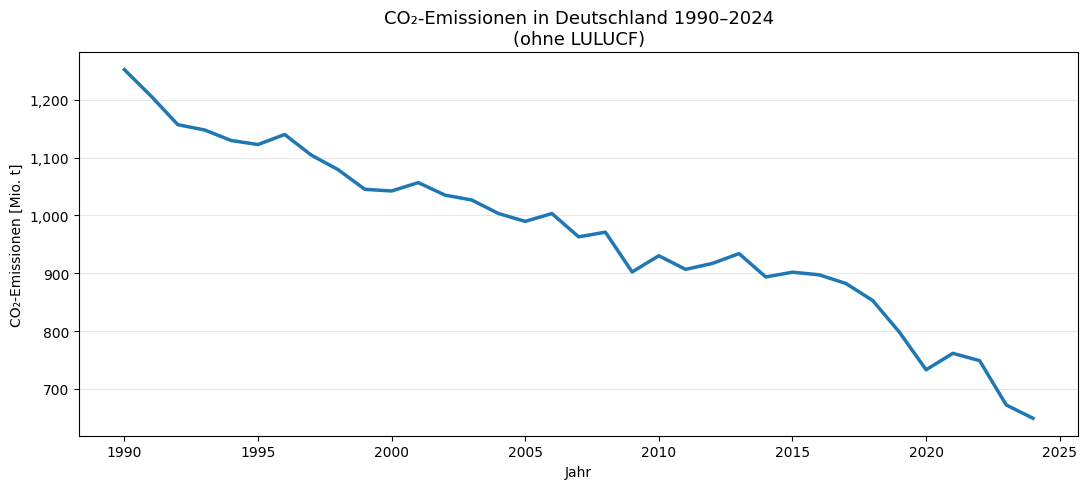

In [12]:
plt.figure(figsize=(11, 5))

plt.plot(
    df_gesamt["Jahr"],
    df_gesamt["CO2_Emissionen_Mio_t"],
    linewidth=2.5
)

plt.title(
    "CO₂-Emissionen in Deutschland 1990–2024\n(ohne LULUCF)",
    fontsize=13
)
plt.xlabel("Jahr")
plt.ylabel("CO₂-Emissionen [Mio. t]")

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}")
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Beobachtung:**

Die CO₂-Emissionen in Deutschland sind seit 1990 insgesamt deutlich gesunken.  
Der Rückgang verläuft jedoch nicht gleichmäßig, sondern beschleunigt sich
insbesondere ab den späten 2010er-Jahren.

## 4. Entwicklung der CO₂-Emissionen nach Hauptsektoren

Im nächsten Schritt werden die CO₂-Emissionen der wichtigsten
Wirtschaftssektoren verglichen, um Unterschiede in der
Emissionsentwicklung sichtbar zu machen.

In [8]:
df_sektoren_plot = df_sektoren[
    ~df_sektoren["Sektor"].str.startswith("7 -")
]

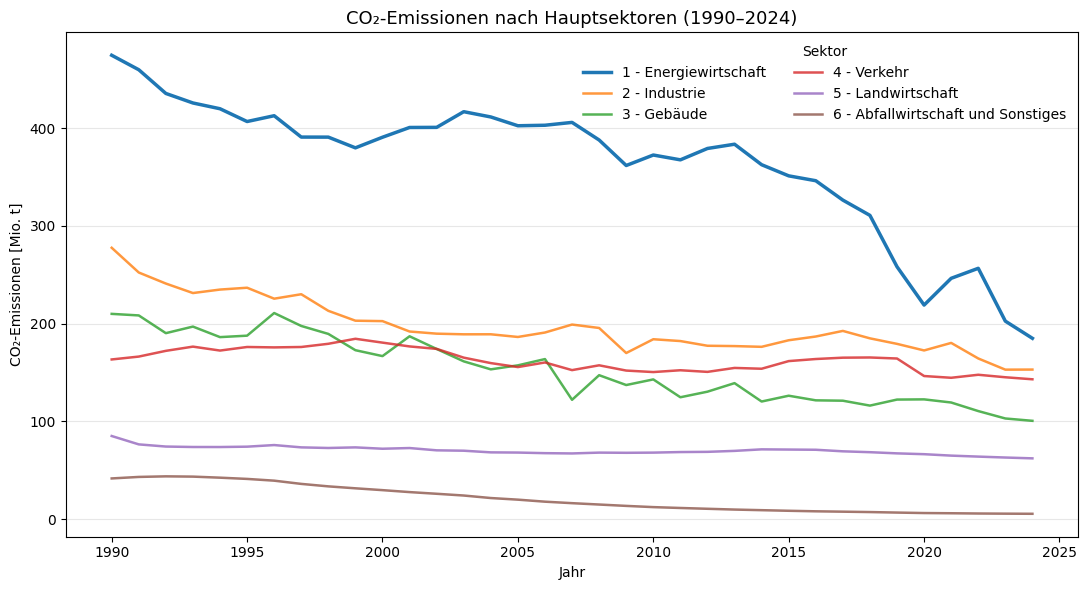

In [9]:
plt.figure(figsize=(11, 6))

for sektor in df_sektoren_plot["Sektor"].unique():
    subset = df_sektoren_plot[df_sektoren_plot["Sektor"] == sektor]

    linewidth = 2.5 if sektor.startswith("1 -") else 1.8
    alpha = 1.0 if sektor.startswith("1 -") else 0.8

    plt.plot(
        subset["Jahr"],
        subset["CO2_Emissionen_Mio_t"],
        label=sektor,
        linewidth=linewidth,
        alpha=alpha
    )

plt.title("CO₂-Emissionen nach Hauptsektoren (1990–2024)", fontsize=13)
plt.xlabel("Jahr")
plt.ylabel("CO₂-Emissionen [Mio. t]")

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}")
)

plt.legend(
    title="Sektor",
    frameon=False,
    ncol=2
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Beobachtungen:**

- Die Energiewirtschaft ist über den gesamten Zeitraum der größte Emittent,
  zeigt jedoch die stärksten absoluten Emissionsreduktionen.
- Der Verkehrssektor weist über Jahrzehnte hinweg kaum strukturelle
  Reduktionen auf.
- Andere Sektoren, wie Industrie und Gebäude, zeigen moderate,
  aber weniger gleichmäßige Rückgänge.

## 6. Fazit

Die Analyse zeigt, dass die CO₂-Emissionen in Deutschland seit 1990
deutlich gesunken sind.  
Besonders die Energiewirtschaft trägt
durch strukturelle Veränderungen maßgeblich zur Emissionsreduktion bei.  
In anderen Sektoren, insbesondere im Verkehr, sind die Fortschritte
deutlich geringer, was auf bestehende strukturelle Herausforderungen hinweist.